In [1]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os 
os.chdir('C:/Users/edwin/OneDrive/Documents/GitHub/CHC')

In [3]:
# import necessary libraries
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

# Define tercile category assignment function

In [4]:
def assign_tercile_category(dataframe, variable_name, dataset_name):
  """Takes a dataframe and a variable name, and returns a dataframe with a column
  for the tercile category of the variable.

  Assumptions:
  Desired model has been converted to dataframe format
  You know the variable of interest to compute terciles for, such as 'precip'

  Usage:
  GFDL_tercile_category_df = assign_tercile_category(GFDL_south_sudan_df, 'predicted_precip', 'GFDL')

  The dataset_name argument makes the dataframe more readable and convenient for analysis

  Returns:
  A dataframe with a column for the tercile category of the variable.
  """

  # Compute tercile thresholds
  lower_tercile = dataframe[variable_name].quantile(0.33)
  upper_tercile = dataframe[variable_name].quantile(0.66)

  # Classify precipitation using vectorized NumPy operations
  conditions = [
        dataframe[variable_name] < lower_tercile,
        dataframe[variable_name] > upper_tercile
    ]
  choices = ["Low", "High"]

  # Assign categories (default is "Medium")
  dataframe[f"tercile_category_{dataset_name}"] = np.select(conditions, choices, default="Medium")

  print(f'Lower Tercile Cutoff for {dataset_name}: {lower_tercile}')
  print(f'Upper Tercile Cutoff for {dataset_name}: {upper_tercile}')

  return dataframe

In [5]:
# Importing the data
#region = ['south_sudan', 'eastern_east_africa', 'eastern_ukraine', 'southern_africa', 'west_africa', 'sri_lanka', 'lake_victoria_basin']
region = ['south_sudan', 'eastern_east_africa']
model = ['CanESM5', 'CCSM4', 'CESM1', 'GEM5', 'GFDL', 'NASA', 'NCEP', 'CMCC', 'DWD', 'ECMWF', 'METEO']

# Create an empty dictionary to store the DataFrames
dataframes = {}

for i in region:
    for j in model:
    # Construct the filename
        filename = f'data/netCDF/{i}_{j}_merged.nc'  # Using f-string for clarity
        try:
            # Load the NetCDF file, convert to DataFrame, and store in the dictionary
            dataframes[(i, j)] = xr.open_mfdataset(filename)

        except FileNotFoundError:
            print(f"Warning: File not found: {filename}")
        except Exception as e:  # Catch other potential errors
            print(f"Error loading file {filename}: {e}")

In [6]:
# initializing starting and ending years
start_year = 1993
end_year = 2020
results = pd.DataFrame()
#region = ['south_sudan', 'eastern_east_africa', 'eastern_ukraine', 'southern_africa', 'west_africa', 'sri_lanka', 'lake_victoria_basin']
region = ['south_sudan', 'eastern_east_africa']
model = ['CanESM5', 'CCSM4', 'CESM1', 'GEM5', 'GFDL', 'NASA', 'NCEP', 'CMCC', 'DWD', 'ECMWF', 'METEO']

for i in region:
    for j in model:
        # Construct the key for the dataframes dictionary
        df_key = (i, j)

        # Check if the DataFrame exists for this region/model combination
        if df_key in dataframes:
            df = dataframes[df_key].to_dataframe().reset_index().dropna()
            df_subset = df[(df['time'].dt.year >= 1993) & (df['time'].dt.year <= 2020)].dropna()
            # if model is CMCC, DWD, ECMWF, METEO then add lead time by 0.5 for all lead time values
            if j in ['CMCC', 'DWD', 'ECMWF', 'METEO']:
                df_subset['lead_time'] = df_subset['lead_time'] + 0.5
        
            # Calculate ensemble mean
            ensemble_means = (df_subset
                              .groupby(['time', 'lead_time', 'latitude', 'longitude'])[['predicted_precip', 'precip']]
                              .mean().reset_index())

            # Extract months
            spatial_means = (ensemble_means  # Use the ensemble_means DataFrame
                              .groupby(['time', 'lead_time'])[['predicted_precip', 'precip']]
                              .mean().reset_index())
            # assign tercile category for both chirps and predicted precip
            tercile_category_df = assign_tercile_category(spatial_means, 'predicted_precip', j)
            tercile_category_df = assign_tercile_category(spatial_means, 'precip', 'chirps')

            tercile_category_df['month'] = tercile_category_df['time'].dt.month
            tercile_category_df['year'] = tercile_category_df['time'].dt.year

            tercile_category_df = tercile_category_df.drop('time', axis=1)

            # compute agreement rate by month and lead time
            tercile_category_df['agreement_rate'] = tercile_category_df['tercile_category_chirps'] == tercile_category_df[f'tercile_category_{j}']

            # subset where chirps categorized precips
            tercile_category_df_low = tercile_category_df[tercile_category_df['tercile_category_chirps'] == 'Low']
            tercile_category_df_medium = tercile_category_df[tercile_category_df['tercile_category_chirps'] == 'Medium']
            tercile_category_df_high = tercile_category_df[tercile_category_df['tercile_category_chirps'] == 'High']

            # mean by year
            tercile_category_df_low = tercile_category_df_low.groupby(['month', 'lead_time'])['agreement_rate'].mean().reset_index()
            tercile_category_df_medium = tercile_category_df_medium.groupby(['month', 'lead_time'])['agreement_rate'].mean().reset_index()
            tercile_category_df_high = tercile_category_df_high.groupby(['month', 'lead_time'])['agreement_rate'].mean().reset_index()

            new_rows_low = []
            new_rows_medium = []
            new_rows_high = []
            # append a row into a pandas dataframe where agreement rate is np.nan if the month and lead time is missing
            for k in range(1, 13):
                for l in range(0, 12):
                    if len(tercile_category_df_low[(tercile_category_df_low['month'] == k) & (tercile_category_df_low['lead_time'] == (l + 0.5))]) == 0:
                        new_rows_low.append({'month': k, 'lead_time': (l + 0.5), 'agreement_rate': np.nan})
                    if len(tercile_category_df_medium[(tercile_category_df_medium['month'] == k) & (tercile_category_df_medium['lead_time'] == (l + 0.5))]) == 0:
                        new_rows_medium.append({'month': k, 'lead_time': (l + 0.5), 'agreement_rate': np.nan})
                    if len(tercile_category_df_high[(tercile_category_df_high['month'] == k) & (tercile_category_df_high['lead_time'] == (l + 0.5))]) == 0:
                        new_rows_high.append({'month': k, 'lead_time': (l + 0.5), 'agreement_rate': np.nan})


            # concatenate the new rows to the original dataframe
            tercile_category_df_low = pd.concat([tercile_category_df_low, pd.DataFrame(new_rows_low)], ignore_index=True)
            tercile_category_df_medium = pd.concat([tercile_category_df_medium, pd.DataFrame(new_rows_medium)], ignore_index=True)
            tercile_category_df_high = pd.concat([tercile_category_df_high, pd.DataFrame(new_rows_high)], ignore_index=True)

            # set the model and category for facet
            tercile_category_df_low['model'] = j
            tercile_category_df_low['region'] = i
            tercile_category_df_low['tercile_analysis'] = 'Low'
            tercile_category_df_medium['model'] = j
            tercile_category_df_medium['region'] = i
            tercile_category_df_medium['tercile_analysis'] = 'Medium'
            tercile_category_df_high['model'] = j
            tercile_category_df_high['region'] = i
            tercile_category_df_high['tercile_analysis'] = 'High'

            # concatenate the results
            results = pd.concat([results, tercile_category_df_low], ignore_index=True)
            results = pd.concat([results, tercile_category_df_medium], ignore_index=True)
            results = pd.concat([results, tercile_category_df_high], ignore_index=True)

Lower Tercile Cutoff for CanESM5: 1.6513171362876893
Upper Tercile Cutoff for CanESM5: 6.524875106811524
Lower Tercile Cutoff for chirps: 28.569272994995117
Upper Tercile Cutoff for chirps: 121.76072692871094
Lower Tercile Cutoff for CCSM4: 3.2799078273773197
Upper Tercile Cutoff for CCSM4: 5.819235830307008
Lower Tercile Cutoff for chirps: 28.94462013244629
Upper Tercile Cutoff for chirps: 127.67627716064453
Lower Tercile Cutoff for CESM1: 2.683731153011322
Upper Tercile Cutoff for CESM1: 5.565538082122803
Lower Tercile Cutoff for chirps: 28.569272994995117
Upper Tercile Cutoff for chirps: 121.76072692871094
Lower Tercile Cutoff for GEM5: 1.807409224510193
Upper Tercile Cutoff for GEM5: 6.155133905410767
Lower Tercile Cutoff for chirps: 28.569272994995117
Upper Tercile Cutoff for chirps: 121.76072692871094
Lower Tercile Cutoff for GFDL: 1.2495379972457885
Upper Tercile Cutoff for GFDL: 4.438329811096192
Lower Tercile Cutoff for chirps: 28.569272994995117
Upper Tercile Cutoff for chirp

In [8]:
results.reset_index()
ss_results = results[results['region'] == 'south_sudan']
eea_results = results[results['region'] == 'eastern_east_africa']
eea_results

,month,lead_time,agreement_rate,model,region,tercile_analysis
4752,1,0.5,1.0,CanESM5,eastern_east_africa,Low
4753,1,1.5,1.0,CanESM5,eastern_east_africa,Low
4754,1,2.5,1.0,CanESM5,eastern_east_africa,Low
4755,1,3.5,1.0,CanESM5,eastern_east_africa,Low
4756,1,4.5,1.0,CanESM5,eastern_east_africa,Low
...,...,...,...,...,...,...
9499,12,7.5,NaN,METEO,eastern_east_africa,High
9500,12,8.5,NaN,METEO,eastern_east_africa,High
9501,12,9.5,NaN,METEO,eastern_east_africa,High
9502,12,10.5,NaN,METEO,eastern_east_africa,High


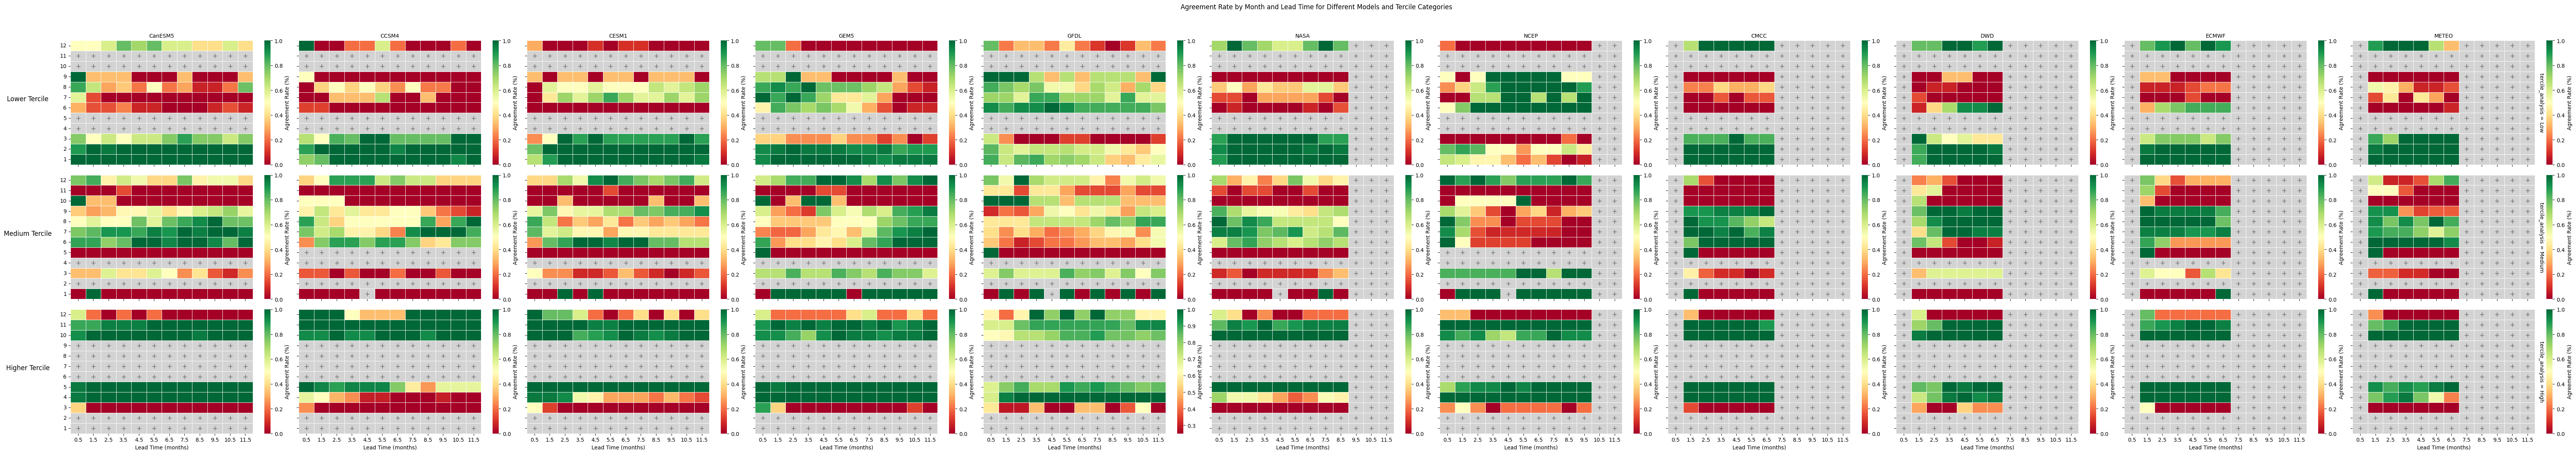

In [10]:
cmap = sns.color_palette("RdYlGn", as_cmap=True)
cmap.set_bad(color="lightgray")  # Set NaN areas to gray

# Create a FacetGrid
g = sns.FacetGrid(eea_results, col="model", row="tercile_analysis", margin_titles=True, height=4, aspect=1.5)

# Define a function to plot the heatmap
def heatmap(data, **kwargs):
    pivot_table = data.pivot(index="month", columns="lead_time", values="agreement_rate")
    pivot_table = pivot_table.dropna(axis=1, how="all")

    # Reindex to include all possible lead_time values up to 11.5
    all_lead_times = np.arange(0.5, 12.5, 1)
    pivot_table = pivot_table.reindex(columns=all_lead_times)

    ax = sns.heatmap(pivot_table, cmap=cmap, annot=False, linewidths=0.5, 
                     cbar_kws={'label': 'Agreement Rate (%)'}, mask=pivot_table.isna(), **kwargs)
    ax.invert_yaxis()
    plt.yticks(rotation=0)
    for i in range(pivot_table.shape[0]):
        for j in range(pivot_table.shape[1]):
            if np.isnan(pivot_table.iloc[i, j]):
                ax.text(j + 0.5, i + 0.5, "+", ha="center", va="center", color="dimgray", fontsize=12)
    plt.xticks(np.arange(0.5, 12.5, 1))

# Map the heatmap function to the FacetGrid
g.map_dataframe(heatmap)

# Adjust the axis labels and titles
g.set_axis_labels("Lead Time (months)", "Month")

# Set the row titles
row_titles = ["Lower Tercile", "Medium Tercile", "Higher Tercile"]
for ax, row_title in zip(g.axes[:, 0], row_titles):
    ax.set_ylabel(row_title, rotation=0, size='large', labelpad=60)
g.set_titles(col_template="{col_name}")

# Set the main title
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Agreement Rate by Month and Lead Time for Different Models and Tercile Categories")

# Show the plot
plt.show()

# Save the plot
output_path = r"figures\eea_tercile_hit_rate.png"
g.savefig(output_path)

In [17]:
# open the merged netcdf
#ss_GFDL = xr.open_dataset('/content/drive/My Drive/capstone_data/netCDF/south_sudan_GFDL_merged.nc')
ss_GFDL = xr.open_dataset('data/netCDF/south_sudan_GFDL_merged.nc')
ss_GFDL

<xarray.Dataset> Size: 469MB
Dimensions:           (lead_time: 12, time: 408, M: 30, latitude: 19,
                       longitude: 21)
Coordinates:
  * lead_time         (lead_time) float32 48B 0.5 1.5 2.5 3.5 ... 9.5 10.5 11.5
  * time              (time) datetime64[ns] 3kB 1991-01-01 ... 2024-12-01
  * M                 (M) float32 120B 1.0 2.0 3.0 4.0 ... 27.0 28.0 29.0 30.0
  * latitude          (latitude) float64 152B 3.5 4.0 4.5 5.0 ... 11.5 12.0 12.5
  * longitude         (longitude) float64 168B 25.0 25.5 26.0 ... 34.0 34.5 35.0
Data variables:
    predicted_precip  (lead_time, time, M, latitude, longitude) float32 234MB ...
    precip            (lead_time, time, M, latitude, longitude) float32 234MB ...

In [5]:
# subset where year is 1993 to 2020
ss_GFDL_df_subset = ss_GFDL_df[(ss_GFDL_df['time'].dt.year >= 1993) & (ss_GFDL_df['time'].dt.year <= 2020)]

# drop na values, these are places where chirps is measuring the ocean etc
ss_GFDL_df = ss_GFDL_df_subset.dropna()

# count how many nans
ss_GFDL_df

,lead_time,time,M,latitude,longitude,predicted_precip,precip
287280,0.5,1993-01-01,1.0,3.5,25.0,1.495804,21.016228
287281,0.5,1993-01-01,1.0,3.5,25.5,1.495804,26.995951
287282,0.5,1993-01-01,1.0,3.5,26.0,1.495231,32.001976
287283,0.5,1993-01-01,1.0,3.5,26.5,1.495231,58.396255
287284,0.5,1993-01-01,1.0,3.5,27.0,4.170642,35.482803
...,...,...,...,...,...,...,...
58012600,11.5,2020-11-01,15.0,12.5,33.0,0.179583,0.931869
58012601,11.5,2020-11-01,15.0,12.5,33.5,0.179583,1.480623
58012602,11.5,2020-11-01,15.0,12.5,34.0,0.116321,1.652255
58012603,11.5,2020-11-01,15.0,12.5,34.5,0.116321,0.967741


In [6]:
# take the ensemble mean and spatial mean
# Calculate ensemble mean
ensemble_means = (ss_GFDL_df
                            .groupby(['time', 'lead_time', 'latitude', 'longitude'])[['predicted_precip', 'precip']]
                            .mean().reset_index())

spatial_means = (ensemble_means  # Use the ensemble_means DataFrame
                              .groupby(['time', 'lead_time'])[['predicted_precip', 'precip']]
                              .mean().reset_index())

spatial_means

,time,lead_time,predicted_precip,precip
0,1993-01-01,0.5,0.322244,5.497239
1,1993-01-01,1.5,0.293955,5.497239
2,1993-01-01,2.5,0.166313,5.497239
3,1993-01-01,3.5,0.151458,5.497239
4,1993-01-01,4.5,0.130135,5.497239
...,...,...,...,...
3938,2020-09-01,11.5,6.515705,143.906601
3939,2020-10-01,10.5,3.727987,109.843300
3940,2020-10-01,11.5,3.245944,109.843300
3941,2020-11-01,11.5,2.367919,26.798523


In [7]:
# assign tercile category for both chirps and gfdl
ss_tercile_category_df = assign_tercile_category(spatial_means, 'predicted_precip', 'GFDL')
ss_tercile_category_df = assign_tercile_category(spatial_means, 'precip', 'chirps')

ss_tercile_category_df['month'] = ss_tercile_category_df['time'].dt.month
ss_tercile_category_df['year'] = ss_tercile_category_df['time'].dt.year

ss_tercile_category_df = ss_tercile_category_df.drop('time', axis=1)

# compute agreement rate by month and lead time
ss_tercile_category_df['agreement_rate'] = ss_tercile_category_df['tercile_category_chirps'] == ss_tercile_category_df['tercile_category_GFDL']

Lower Tercile Cutoff for GFDL: 1.2495379972457885
Upper Tercile Cutoff for GFDL: 4.438329811096192
Lower Tercile Cutoff for chirps: 28.569272994995117
Upper Tercile Cutoff for chirps: 121.76072692871094


In [8]:
ss_tercile_category_df

,lead_time,predicted_precip,precip,tercile_category_GFDL,tercile_category_chirps,month,year,agreement_rate
0,0.5,0.322244,5.497239,Low,Low,1,1993,True
1,1.5,0.293955,5.497239,Low,Low,1,1993,True
2,2.5,0.166313,5.497239,Low,Low,1,1993,True
3,3.5,0.151458,5.497239,Low,Low,1,1993,True
4,4.5,0.130135,5.497239,Low,Low,1,1993,True
...,...,...,...,...,...,...,...,...
3938,11.5,6.515705,143.906601,High,High,9,2020,True
3939,10.5,3.727987,109.843300,Medium,Medium,10,2020,True
3940,11.5,3.245944,109.843300,Medium,Medium,10,2020,True
3941,11.5,2.367919,26.798523,Medium,Low,11,2020,False


### now, we have a dataframe with the tercile categories of chirps and GFDL for south sudan (average precip over the region), as well as a boolean column for their agreement (T/F)

In [ ]:
# subset where chirps categorized precip as low
ss_tercile_category_df_low = ss_tercile_category_df[ss_tercile_category_df['tercile_category_chirps'] == 'Low']

# mean by year
ss_tercile_category_df_low = ss_tercile_category_df_low.groupby(['month', 'lead_time'])['agreement_rate'].mean().reset_index()

new_rows = []
# append a row into a pandas dataframe where agreement rate is -1 if the month and lead time is missing
for i in range(1, 13):
    for j in range(0, 12):
        if not ((ss_tercile_category_df_low['month'] == i) & (ss_tercile_category_df_low['lead_time'] == (j + 0.5))).any():
            new_rows.append({'month': i, 'lead_time': (j + 0.5), 'agreement_rate': -1})

# concatenate the new rows to the original dataframe
ss_tercile_category_df_low = pd.concat([ss_tercile_category_df_low, pd.DataFrame(new_rows)], ignore_index=True)

# set the model and category for facet
ss_tercile_category_df_low['model'] = 'GFDL'
ss_tercile_category_df_low['region'] = 'South Sudan'
ss_tercile_category_df_low['tercile_category'] = 'Low'

# view data
ss_tercile_category_df_low

,month,lead_time,agreement_rate,model,region,tercile_category
0,1,0.5,1.0,GFDL,South Sudan,Low
1,1,1.5,1.0,GFDL,South Sudan,Low
2,1,2.5,1.0,GFDL,South Sudan,Low
3,1,3.5,1.0,GFDL,South Sudan,Low
4,1,4.5,1.0,GFDL,South Sudan,Low
...,...,...,...,...,...,...
139,10,7.5,-1.0,GFDL,South Sudan,Low
140,10,8.5,-1.0,GFDL,South Sudan,Low
141,10,9.5,-1.0,GFDL,South Sudan,Low
142,10,10.5,-1.0,GFDL,South Sudan,Low


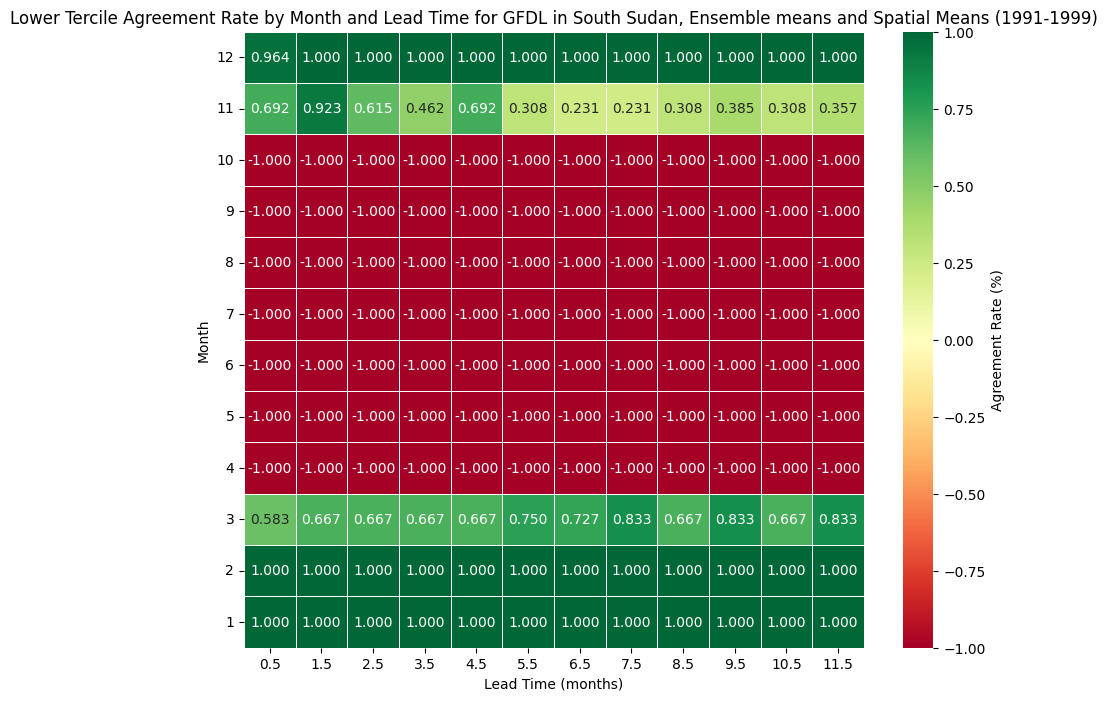

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

pivot_table = ss_tercile_category_df_high.pivot(index="month", columns="lead_time", values="agreement_rate")

# Set up the figure
plt.figure(figsize=(10, 8))

# Create the heatmap
ax = sns.heatmap(pivot_table, cmap="RdYlGn", annot=True, fmt=".3f", linewidths=0.5, cbar_kws={'label': 'Agreement Rate (%)'})

# make it so that
ax.invert_yaxis()

plt.yticks(rotation=0)

# Labels and title
plt.xlabel("Lead Time (months)")
plt.ylabel("Month")
plt.title("Lower Tercile Agreement Rate by Month and Lead Time for GFDL in South Sudan, Ensemble means and Spatial Means (1991-1999)")

# Show the plot
plt.show()

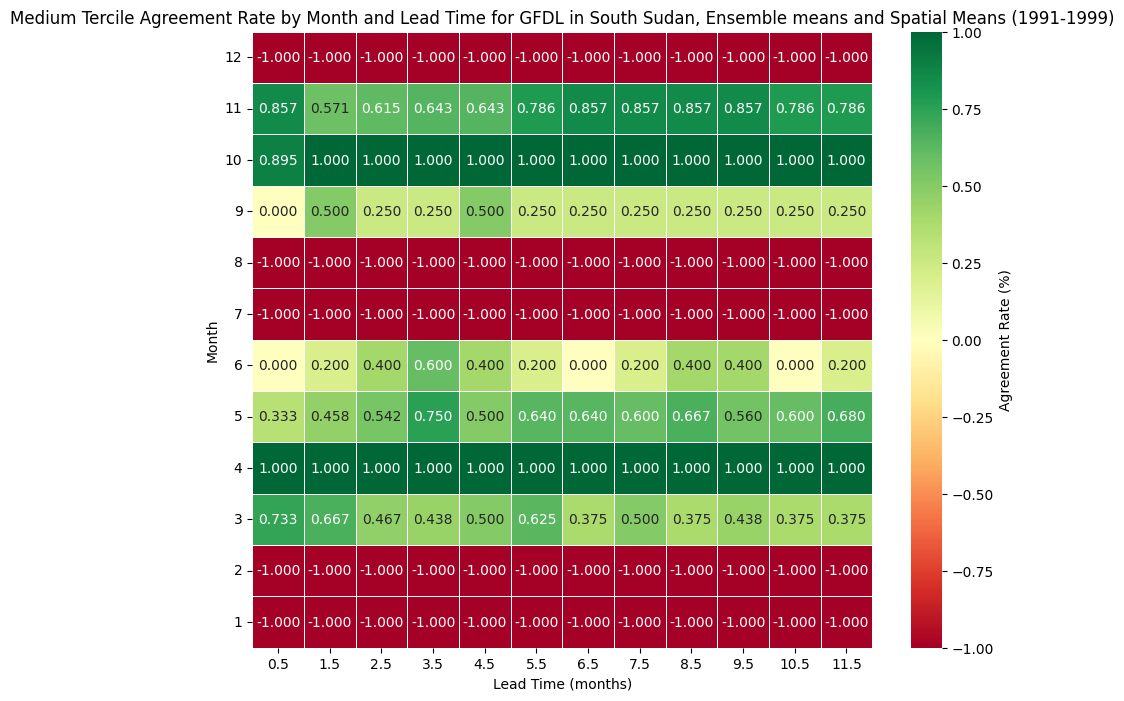

In [ ]:
# subset where chirps categorized precip as medium
ss_tercile_analysis_df_medium = ss_tercile_category_df[ss_tercile_category_df['tercile_category_chirps'] == 'Medium']

# mean by year
ss_tercile_analysis_df_medium = ss_tercile_analysis_df_medium.groupby(['month', 'lead_time'])['agreement_rate'].mean().reset_index()


new_rows = []
# append a row into a pandas dataframe where agreement rate is -1 if the month and lead time is missing
for i in range(1, 13):
    for j in range(0, 12):
        if not ((ss_tercile_analysis_df_medium['month'] == i) & (ss_tercile_analysis_df_medium['lead_time'] == (j + 0.5))).any():
            new_rows.append({'month': i, 'lead_time': (j + 0.5), 'agreement_rate': -1})

# concatenate the new rows to the original dataframe
ss_tercile_analysis_df_medium = pd.concat([ss_tercile_analysis_df_medium, pd.DataFrame(new_rows)], ignore_index=True)

# set the model and category for facet
ss_tercile_analysis_df_medium['model'] = 'GFDL'
ss_tercile_analysis_df_medium['region'] = 'South Sudan'
ss_tercile_analysis_df_medium['tercile_category'] = 'Medium'

# view data
ss_tercile_analysis_df_medium

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

pivot_table = ss_tercile_analysis_df_medium.pivot(index="month", columns="lead_time", values="agreement_rate")

# Set up the figure
plt.figure(figsize=(10, 8))

# Create the heatmap
ax = sns.heatmap(pivot_table, cmap="RdYlGn", annot=True, fmt=".3f", linewidths=0.5, cbar_kws={'label': 'Agreement Rate (%)'})

# make it so that
ax.invert_yaxis()

plt.yticks(rotation=0)

# Labels and title
plt.xlabel("Lead Time (months)")
plt.ylabel("Month")
plt.title(f"Medium Tercile Agreement Rate by Month and Lead Time for GFDL in South Sudan, Ensemble means and Spatial Means (1991-1999)")

# Show the plot
plt.show()

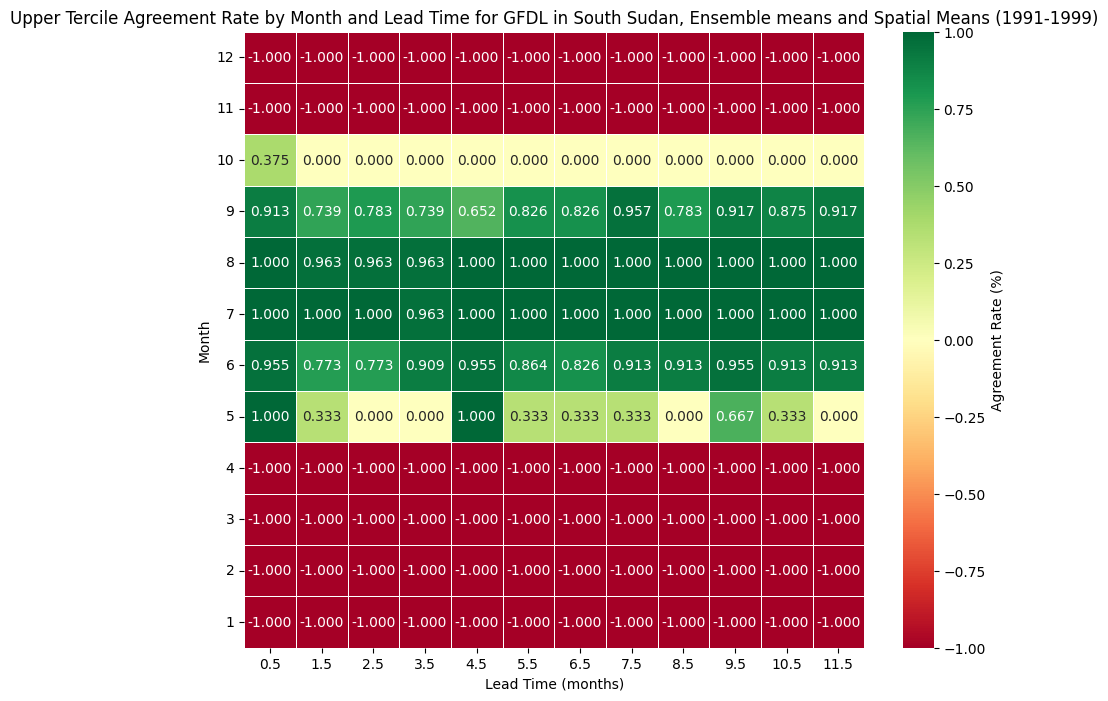

In [ ]:
# subset where chirps categorized precip as high
ss_tercile_category_df_high = ss_tercile_category_df[ss_tercile_category_df['tercile_category_chirps'] == 'High']

# mean by year
ss_tercile_category_df_high = ss_tercile_category_df_high.groupby(['month', 'lead_time'])['agreement_rate'].mean().reset_index()

new_rows = []
# append a row into a pandas dataframe where agreement rate is -1 if the month and lead time is missing
for i in range(1, 13):
    for j in range(0, 12):
        if not ((ss_tercile_category_df_high['month'] == i) & (ss_tercile_category_df_high['lead_time'] == (j + 0.5))).any():
            new_rows.append({'month': i, 'lead_time': (j + 0.5), 'agreement_rate': -1})

# concatenate the new rows to the original dataframe
ss_tercile_category_df_high = pd.concat([ss_tercile_category_df_high, pd.DataFrame(new_rows)], ignore_index=True)

# set the model and category for facet
ss_tercile_category_df_high['model'] = 'GFDL'
ss_tercile_category_df_high['region'] = 'South Sudan'
ss_tercile_category_df_high['tercile_category'] = 'High'

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

pivot_table = ss_tercile_category_df_high.pivot(index="month", columns="lead_time", values="agreement_rate")

# Set up the figure
plt.figure(figsize=(10, 8))

# Create the heatmap
ax = sns.heatmap(pivot_table, cmap="RdYlGn", annot=True, fmt=".3f", linewidths=0.5, cbar_kws={'label': 'Agreement Rate (%)'})

# make it so that
ax.invert_yaxis()

plt.yticks(rotation=0)

# Labels and title
plt.xlabel("Lead Time (months)")
plt.ylabel("Month")
plt.title(f"Upper Tercile Agreement Rate by Month and Lead Time for GFDL in South Sudan, Ensemble means and Spatial Means (1991-1999)")

# Show the plot
plt.show()